# Setup 

In [ ]:

import matplotlib.patches as patches
from pathlib import Path
import sys
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
product_month_inventory_fact_df = pd.read_csv(str(PROJECT_ROOT) + '/data/derived/product_month_inventory_fact.csv')
print('Load product_month_inventory_fact successful')
product_month_inventory_fact_df


Load product_month_inventory_fact successful


,product_id,snapshot_date,snapshot_month,year,month,product_name,category,segment,stock_on_hand,units_received,...,net_units_change,available_units,stockout_days,stockout_rate_days,days_of_supply,fill_rate,sell_through_rate,stockout_flag,overstock_flag,reorder_flag
0,1,2022-10-31,2022-10-01,2022,10,DragonWear MA-01,Casual,All-weather,3,1,...,0,4,2,0.064516,90.0,0.9333,0.2500,1,0,0
1,1,2022-11-30,2022-11-01,2022,11,DragonWear MA-01,Casual,All-weather,3,1,...,0,4,1,0.033333,90.0,0.9667,0.2500,1,0,0
2,1,2022-12-31,2022-12-01,2022,12,DragonWear MA-01,Casual,All-weather,3,1,...,0,4,1,0.032258,90.0,0.9667,0.2500,1,0,0
3,3,2016-04-30,2016-04-01,2016,4,DragonWear MA-03,Casual,All-weather,35,13,...,2,46,2,0.066667,95.5,0.9333,0.2391,1,1,0
4,3,2016-05-31,2016-05-01,2016,5,DragonWear MA-03,Casual,All-weather,36,11,...,1,46,1,0.032258,108.0,0.9667,0.2174,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60242,2412,2022-08-31,2022-08-01,2022,8,VietMotion YY-21,GenZ,Trendy,251,25,...,4,272,2,0.064516,358.6,0.9333,0.0772,1,1,0
60243,2412,2022-09-30,2022-09-01,2022,9,VietMotion YY-21,GenZ,Trendy,251,3,...,0,254,2,0.066667,2510.0,0.9333,0.0118,1,1,0
60244,2412,2022-10-31,2022-10-01,2022,10,VietMotion YY-21,GenZ,Trendy,251,3,...,0,254,0,0.000000,2510.0,1.0000,0.0118,0,1,0
60245,2412,2022-11-30,2022-11-01,2022,11,VietMotion YY-21,GenZ,Trendy,251,3,...,0,254,0,0.000000,2510.0,1.0000,0.0118,0,1,0


# Prepare data for chart 6 

In [ ]:
print(product_month_inventory_fact_df['year'].value_counts().sort_index())

product_month_inventory_fact_df['Period'] = np.where(
    product_month_inventory_fact_df['year'] >= 2018, 'Recent (2018-2022)', 'Past (2012-2017)'
)

product_month_inventory_fact_df['Period'].value_counts()

year
2012    2539
2013    5570
2014    5787
2015    5872
2016    5927
2017    6084
2018    6106
2019    5835
2020    5686
2021    5609
2022    5232
Name: count, dtype: int64


Period
Past (2012-2017)      31779
Recent (2018-2022)    28468
Name: count, dtype: int64

## Câu dẫn từ Demand sang chart 6
- Tuy nhiên, mọi nỗ lực đơn giản hóa hành trình hay kích thích khách hàng quay lại ở phần Demand-side sẽ hoàn toàn vô nghĩa nếu rơi vào cảnh: Khách muốn mua nhưng kho không có hàng. Vậy hệ thống tồn kho của chúng ta đang đáp ứng nhu cầu thực tế này ra sao? Bức tranh Supply-side sẽ được mở đầu bằng Chart 6, và nó dội ngay một gáo nước lạnh: Chúng ta không chỉ thiếu hàng, mà còn đang liên tục 'lỗi nhịp' với thời điểm mua sắm của khách.

# Chart 6: Stockout Rate
## Heatmap category/month (Recent(2018 - 2022) vs Past(2012 - 2017))

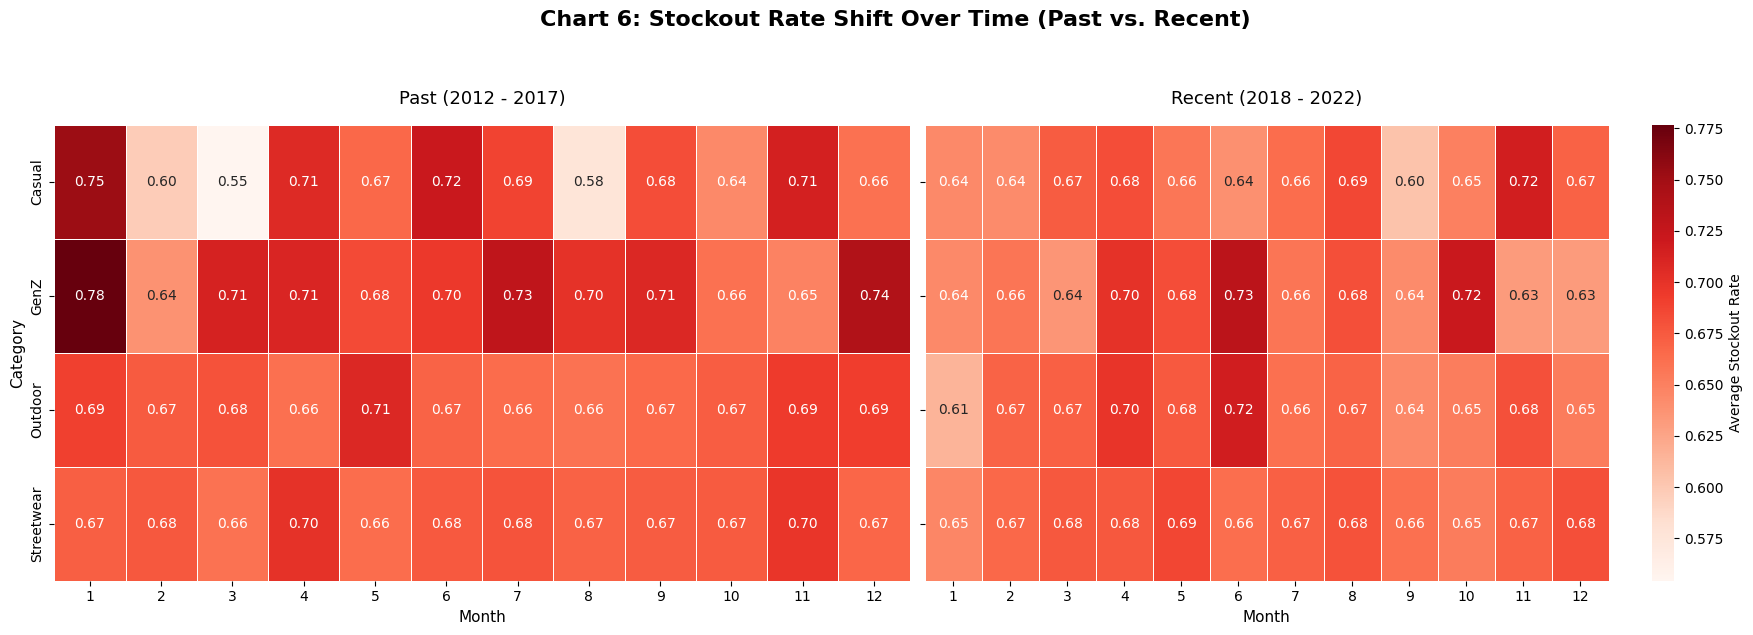

In [ ]:
heatmap_data_split = product_month_inventory_fact_df.groupby(
    ['category', 'Period', 'month']
)['stockout_flag'].mean().unstack(['Period', 'month'])


past_data = heatmap_data_split['Past (2012-2017)']
recent_data = heatmap_data_split['Recent (2018-2022)']


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
fig.suptitle('Chart 6: Stockout Rate Shift Over Time (Past vs. Recent)', fontsize=16, weight='bold', y=1.05)


vmin_val = min(past_data.min().min(), recent_data.min().min())
vmax_val = max(past_data.max().max(), recent_data.max().max())

# Past plot
sns.heatmap(
    past_data, 
    cmap='Reds', 
    annot=True, 
    fmt=".2f", 
    ax=ax1, 
    vmin=vmin_val, 
    vmax=vmax_val, 
    cbar=False, 
    linewidths=0.5
)
ax1.set_title('Past (2012 - 2017)', pad=15, fontsize=13)
ax1.set_xlabel('Month', fontsize=11)
ax1.set_ylabel('Category', fontsize=11)

# Recent plot
sns.heatmap(
    recent_data, 
    cmap='Reds', 
    annot=True, 
    fmt=".2f", 
    ax=ax2, 
    vmin=vmin_val, 
    vmax=vmax_val, 
    linewidths=0.5,
    cbar_kws={'label': 'Average Stockout Rate'}
)
ax2.set_title('Recent (2018 - 2022)', pad=15, fontsize=13)
ax2.set_xlabel('Month', fontsize=11)
ax2.set_ylabel('') 

plt.tight_layout()
plt.show()

## Chart 6: Phân tích Sự dịch chuyển rủi ro đứt gãy nguồn cung (Past vs. Recent)

### Overview
- Gần như toàn bộ các ô màu đều có tỷ lệ đứt hàng $\ge 0.5$ (50%).

$\rightarrow$ Bất kể lúc nào, ở bất kỳ dòng sản phẩm nào, xác suất khách hàng không mua được món đồ họ muốn luôn lớn hơn hoặc bằng 50%. Đây không còn là sự sai lệch mùa vụ nữa, mà hệ thống cung ứng đang thực sự 'khát hàng' một cách mãn tính.

- Mức đỉnh (đỏ đậm nhất) của toàn hệ thống đã giảm nhẹ. Ở giai đoạn Past (2012-2017), ô cao nhất đạt mức 0.78. Sang giai đoạn Recent (2018-2022), ô cao nhất hạ xuống mức 0.73.

$\rightarrow$ Tình trạng đứt hàng tổng thể không hề tệ đi. Vấn đề thực sự là "điểm rơi" của các tháng bị thiếu hàng đã bị dịch chuyển hoàn toàn sang các thời điểm khác trong năm.

### GenZ
- **Giai đoạn Past**: Tháng 1 và Tháng 12 thiếu hàng nặng nề nhất (tỷ lệ chạm đỉnh 0.78 và 0.74)
- **Giai đoạn Recent**: Tháng 1 và Tháng 12 giảm rất mạnh (trở thành màu cam nhạt, chỉ còn 0.64 và 0.63). Thay vào đó, Tháng 6 và Tháng 10 lại vọt lên thành vùng đỏ đậm nhất mới (0.73 và 0.72)

$\rightarrow$ Doanh nghiệp đã khắc phục xuất sắc lỗi đứt hàng dịp đầu/cuối năm của tập khách hàng trẻ. Tuy nhiên, hành vi mua sắm đã chuyển đổi sang giữa mùa Hè và mùa Thu, khiến lịch nhập hàng hiện tại bị "trễ nhịp" và hụt hơi

### Casual
- Tháng 1 đã cải thiện tỷ lệ đứt hàng rất tốt (hạ từ 0.75 xuống 0.64). Tuy nhiên, hiện tại Tháng 11 lại vọt lên thành tháng đỏ đậm nhất (0.72).

$\rightarrow$ Khâu chuẩn bị hàng hóa đầu năm đã ổn, nhưng hệ thống lại đang để "thủng lưới" thiếu hàng trầm trọng vào Tháng 11 - thời điểm thường diễn ra các đợt Mega Sale như Black Friday hay chuẩn bị Lễ hội cuối năm

### Outdoor & Streetwear
- Tỷ lệ đứt hàng của 2 nhóm này duy trì rất "đều" qua tất cả các tháng (dao động chủ yếu ở mốc 0.65 - 0.70) và gần như không có sự thay đổi lột xác nào giữa giai đoạn Past và Recent. (Chỉ có điểm nhấn nhỏ là Outdoor Tháng 6 tăng từ 0.67 lên 0.72)

$\rightarrow$ Tình trạng đứt hàng của 2 nhóm này mang tính chất rải rác, mãn tính quanh năm. Sự bất ổn này không bắt nguồn từ mùa vụ mà khả năng cao đến từ khâu lập kế hoạch dự báo cơ bản bị sai lệch.

### Đề xuất hành động:
- Tái cấu trúc toàn bộ lịch nhập hàng ngay lập tức – rút ngân sách dự trữ 'thừa' ở đầu và cuối năm để dồn trọn lực cho sóng mua sắm Hè-Thu của GenZ, đồng thời kích hoạt bơm kho sớm dòng Casual từ tháng 10 để chặn đứng 'lời nguyền' mất hàng mùa Mega Sale (Tháng 11).

## Câu dẫn từ chart 6 sang 7:

- Nếu như biểu đồ nhiệt vừa rồi cho chúng ta thấy hệ thống đang bị 'sai nhịp về mặt thời gian', thì Ma trận Bong bóng ngay sau đây sẽ bóc trần hệ quả trực tiếp của nó: Dòng tiền của công ty đang bị giam lãng phí ở đâu, và chúng ta đang để tiền rơi qua kẽ tay ở những mảng nào.


# Chart 7: Stockout vs overstock matrix (segment)

## Prepare data for chart 7

In [ ]:

COL_STOCKOUT = 'stockout_flag'      
COL_OVERSTOCK = 'overstock_flag'    
COL_VOLUME = 'units_sold'          


chart7_data = product_month_inventory_fact_df.groupby(['category', 'segment']).agg(
    stockout_rate=(COL_STOCKOUT, 'mean'),
    overstock_rate=(COL_OVERSTOCK, 'mean'),
    total_volume=(COL_VOLUME, 'sum') 
).reset_index()

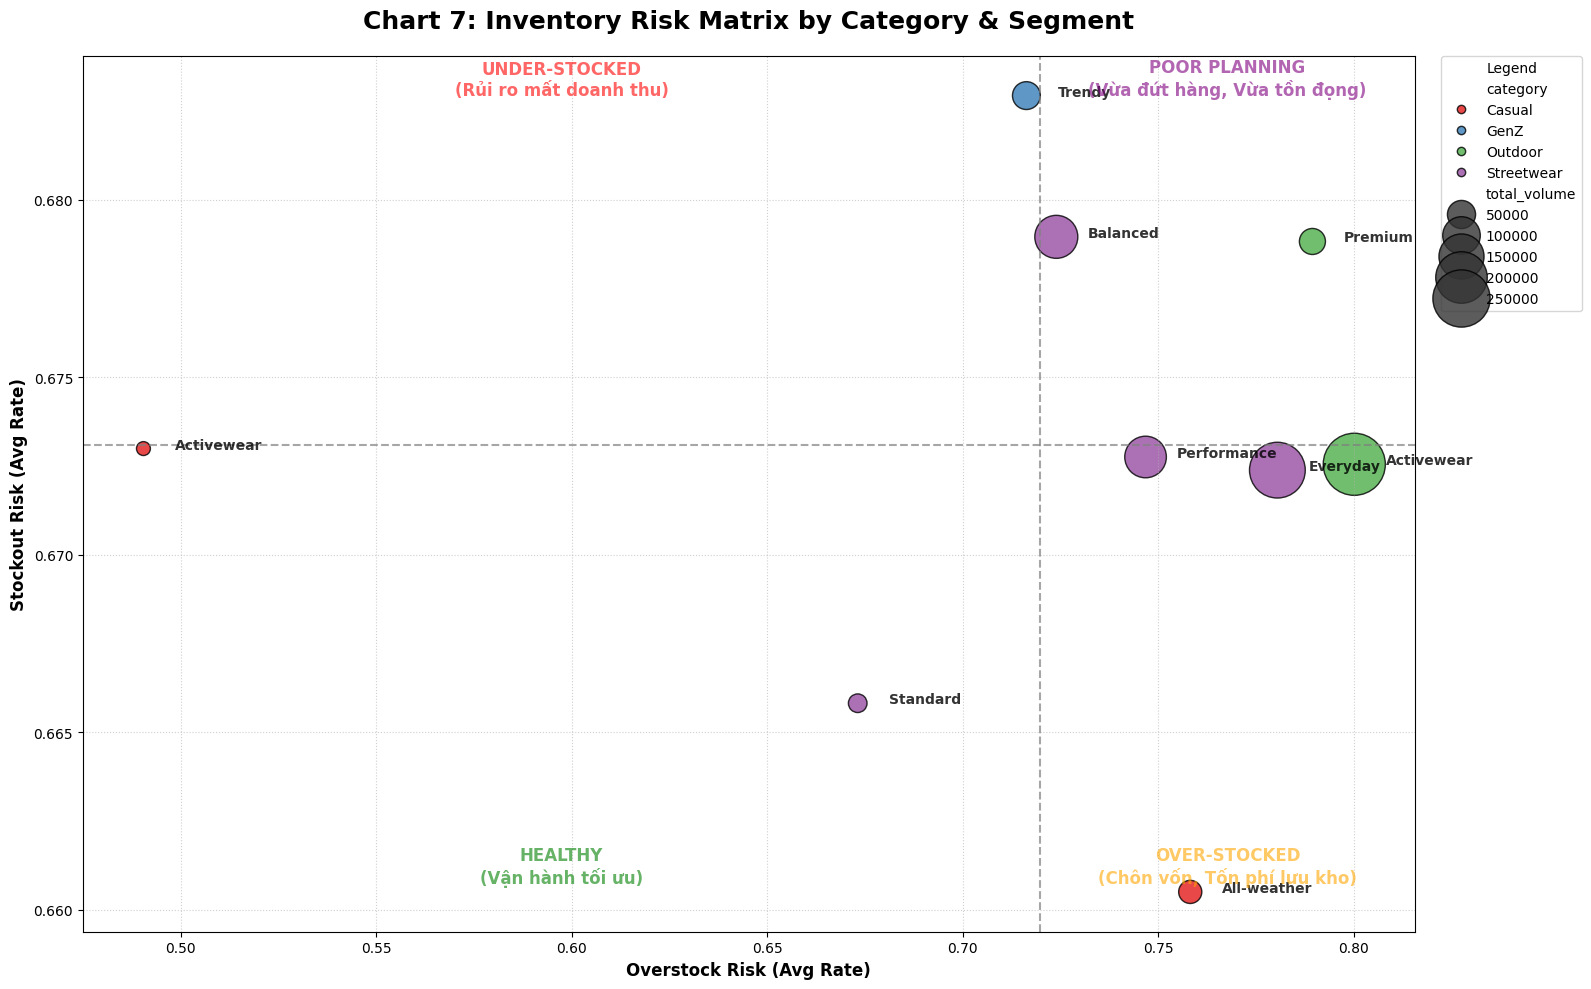

In [ ]:



plt.figure(figsize=(16, 10))


scatter = sns.scatterplot(
    data=chart7_data,
    x='overstock_rate',
    y='stockout_rate',
    hue='category',           
    size='total_volume',   
    sizes=(100, 2000),     
    alpha=0.8,
    palette='Set1',
    edgecolor='black'
)


med_overstock = chart7_data['overstock_rate'].median()
med_stockout = chart7_data['stockout_rate'].median()


plt.axvline(med_overstock, color='grey', linestyle='--', alpha=0.7, linewidth=1.5)
plt.axhline(med_stockout, color='grey', linestyle='--', alpha=0.7, linewidth=1.5)


for i in range(chart7_data.shape[0]):
    plt.text(
        x=chart7_data['overstock_rate'].iloc[i] + (chart7_data['overstock_rate'].max() * 0.01), 
        y=chart7_data['stockout_rate'].iloc[i],
        s=chart7_data['segment'].iloc[i],
        fontdict=dict(color='black', size=10, weight='semibold'),
        alpha=0.8
    )


x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()

plt.text(x_min + (med_overstock - x_min)/2, y_max - (y_max - med_stockout)*0.1, 
         'UNDER-STOCKED\n(Rủi ro mất doanh thu)', color='red', fontsize=12, fontweight='bold', ha='center', alpha=0.6)

plt.text(med_overstock + (x_max - med_overstock)/2, y_max - (y_max - med_stockout)*0.1, 
         'POOR PLANNING\n(Vừa đứt hàng, Vừa tồn đọng)', color='purple', fontsize=12, fontweight='bold', ha='center', alpha=0.6)

plt.text(x_min + (med_overstock - x_min)/2, y_min + (med_stockout - y_min)*0.1, 
         'HEALTHY\n(Vận hành tối ưu)', color='green', fontsize=12, fontweight='bold', ha='center', alpha=0.6)

plt.text(med_overstock + (x_max - med_overstock)/2, y_min + (med_stockout - y_min)*0.1, 
         'OVER-STOCKED\n(Chôn vốn, Tốn phí lưu kho)', color='orange', fontsize=12, fontweight='bold', ha='center', alpha=0.6)


plt.title('Chart 7: Inventory Risk Matrix by Category & Segment', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Overstock Risk (Avg Rate)', fontsize=12, fontweight='bold')
plt.ylabel('Stockout Risk (Avg Rate)', fontsize=12, fontweight='bold')

handles, labels = scatter.get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., title="Legend")

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## Phân tích Chart 7: Ma trận rủi ro tồn kho (Phân rã theo Segment)
### Phân bổ vốn sai
- Các chấm màu đỏ (Casual) nằm ở hai thái cực hoàn toàn đối lập. Phân khúc Casual_Activewear nằm tít ở rìa trái của vùng UNDER-STOCKED (Overstock cực thấp ~0.49). Trong khi đó, Casual_All-weather lại nằm sâu dưới đáy vùng OVER-STOCKED (Overstock cao ~0.76, Stockout thấp nhất hệ thống ~0.660).

$\rightarrow$ Hệ thống đang phân bổ vốn hoàn toàn sai lệch cho danh mục Casual: bỏ qua nguồn cung của dòng Activewear nhưng lại bơm thừa vào dòng All-weather.

### Thất thoát doanh thu
- Bong bóng màu xanh dương GenZ_Trendy nằm ở vùng UNDER-STOCKED có vị trí cao nhất trên trục Y (đứt hàng nặng nhất ~0.683) và kích thước bong bóng thuộc nhóm to nhất.

$\rightarrow$ Đây là "lỗ đen" làm thất thoát doanh thu nặng nề nhất. Sản phẩm có volume bán ra cực lớn nhưng lại liên tục thiếu hàng để bán.

- Tương tự, bong bóng màu tím Streetwear_Balanced cũng rất to và nằm trong vùng thiếu hàng.

### Poor Planning
- Hai bong bóng khổng lồ Outdoor_Activewear và Streetwear_Everyday kẹt cứng ở vùng Over_stocked. Đặc biệt, Outdoor_Premium rơi hẳn vào góc Poor Planning (Overstock cao, Stockout cũng cao).

$\rightarrow$ Vốn đang bị lãng phí nghiêm trọng ở đây. Dòng Premium khả năng cao nhập sai cơ cấu: thừa size kén khách, thiếu hụt size phổ thông.

### Báo động đỏ toàn hệ thống
- Chỉ duy nhất 1 chấm nhỏ Streetwear_Standard nằm ở vùng Healthy.

$\rightarrow$ Gần như toàn bộ các dòng sản phẩm trọng điểm đều đang quản lý tồn kho thất bại, chứng tỏ mô hình dự báo chung đã không còn tác dụng

### Đề xuất hành động
- Đóng băng ngay ngân sách thu mua của các nhóm đang ứ đọng vốn (như Casual_All-weather) để dồn toàn lực bơm hàng, cứu doanh thu cho các phân khúc đang đứt gãy nghiêm trọng (đặc biệt là GenZ_Trendy và Casual_Activewear)